# CS 231 Final Project: Predicting Super Bowl Contenders

## 0. Introduction

This project analyzes NFL team data from 2003–2023 to determine which regular-season characteristics are most associated with Super Bowl success.

The main research question is:

**Which team-level statistics best predict Super Bowl winners, and can we identify realistic championship contenders using machine learning?**

This is a classification problem, but due to extreme class imbalance (only one winner per season), we also use ranking-based evaluation to assess model performance.

This notebook follows a full data science workflow:
1. Data loading and inspection  
2. Target variable creation  
3. Exploratory analysis  
4. Feature selection  
5. Model development  
6. Evaluation and comparison  
7. Final interpretation

In [259]:
# ============================================
# Setup and Imports
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from pathlib import Path

# Reproducibility
np.random.seed(42)
random.seed(42)

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

print("Setup complete.")
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)

Setup complete.
NumPy version: 2.0.2
pandas version: 2.2.2


## 1. Data Overview

### Initial Data Inspection

Before constructing the target variable or performing analysis, the dataset is inspected to confirm:
- structure and dimensions,
- column types,
- and overall data integrity.

This step ensures the dataset is suitable for analysis and modeling.

In [260]:
# ============================================
# Load Raw Dataset
# ============================================

file_name = "team_stats_2003_2023.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (672, 35)


### Dataset Description

The dataset used in this project is the **NFL Team Data 2003–2023** dataset from Kaggle.

**Source:** Kaggle NFL Team Data 2003–2023  
**URL:** https://www.kaggle.com/datasets/nickcantalupa/nfl-team-data-2003-2023

The dataset contains **672 rows and 35 columns**, where each row represents a single NFL team in a single season.

The dataset contains team-level regular-season statistics, including variables related to:
- scoring,
- defense,
- total offensive production,
- turnovers,
- efficiency,
- and team record.

Because the dataset is already structured and mostly numeric, it is well suited for supervised machine learning. The initial inspection in this section is used to verify the dataset structure before any target construction or modeling decisions are made.

In [261]:
# ============================================
# Preview the Dataset
# ============================================

df.head()

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,pass_att,pass_yds,pass_td,pass_int,pass_net_yds_per_att,pass_fd,rush_att,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,5039,1042,4.8,24,11,294,320,537,3432,23,13,6.0,177,473,1607,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,4609,968,4.8,34,15,266,257,450,2792,17,19,5.8,145,487,1817,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,4348,980,4.4,34,17,268,293,502,2684,11,17,4.9,150,427,1664,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,4951,936,5.3,20,6,274,312,496,3316,20,14,6.3,181,409,1635,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,4929,1009,4.9,38,19,259,217,415,2255,16,19,4.9,121,552,2674,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN


The first few rows help verify that each observation appears to represent a single NFL team in a single season. This is an important structural check before we examine data types, missing values, or build a target variable.

In [262]:
# ============================================
# Inspect Columns and Data Types
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  672 non-null    int64  
 1   team                  672 non-null    object 
 2   wins                  672 non-null    int64  
 3   losses                672 non-null    int64  
 4   win_loss_perc         672 non-null    float64
 5   points                672 non-null    int64  
 6   points_opp            672 non-null    int64  
 7   points_diff           672 non-null    int64  
 8   mov                   352 non-null    float64
 9   g                     672 non-null    int64  
 10  total_yards           672 non-null    int64  
 11  plays_offense         672 non-null    int64  
 12  yds_per_play_offense  672 non-null    float64
 13  turnovers             672 non-null    int64  
 14  fumbles_lost          672 non-null    int64  
 15  first_down            6

In [263]:
# ============================================
# Summary Statistics for Numeric Variables
# ============================================

df.describe()

,year,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,pass_att,pass_yds,pass_td,pass_int,pass_net_yds_per_att,pass_fd,rush_att,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
count,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,352.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,320.000000
mean,2013.000000,8.050595,8.050595,0.500246,358.633929,358.633929,0.000000,-0.001136,16.139881,5463.895833,1021.910714,5.340476,24.708333,10.062500,314.375000,339.305060,546.882440,3616.974702,23.580357,14.645833,6.187649,186.709821,437.812500,1846.921131,13.462798,4.199554,99.775298,101.494048,849.501488,27.889881,34.093304,12.561756,-35.937113,0.081250
std,6.059811,3.093255,3.086020,0.191452,72.092050,57.889328,100.684601,6.313288,0.347122,628.209466,51.207049,0.507939,6.604748,3.517759,38.462041,50.645939,61.830229,618.130242,7.579648,4.775388,0.785266,31.236190,51.825202,343.221633,5.170285,0.440718,20.837354,16.145851,146.167034,7.251892,6.730800,3.206515,120.556255,0.273647
min,2003.000000,0.000000,0.000000,0.000000,168.000000,201.000000,-261.000000,-16.300000,16.000000,3587.000000,865.000000,3.900000,8.000000,2.000000,191.000000,204.000000,358.000000,1898.000000,7.000000,2.000000,4.100000,96.000000,304.000000,1129.000000,2.000000,3.100000,53.000000,55.000000,415.000000,9.000000,16.400000,4.000000,-358.270000,0.000000
25%,2008.000000,6.000000,6.000000,0.375000,305.000000,316.750000,-75.000000,-4.700000,16.000000,5030.250000,990.000000,5.000000,20.000000,8.000000,288.000000,303.000000,506.750000,3156.250000,18.000000,11.000000,5.700000,163.000000,401.000000,1606.000000,10.000000,3.900000,84.000000,91.000000,751.750000,23.000000,29.200000,10.200000,-124.015000,0.000000
50%,2013.000000,8.000000,8.000000,0.500000,359.000000,356.500000,-1.000000,0.000000,16.000000,5467.500000,1019.000000,5.300000,24.000000,10.000000,313.000000,339.000000,546.000000,3592.500000,23.000000,14.000000,6.100000,186.000000,433.500000,1810.000000,13.000000,4.200000,98.000000,102.000000,852.500000,27.000000,33.900000,12.400000,-40.970000,0.000000
75%,2018.000000,10.000000,10.000000,0.625000,406.000000,398.000000,75.250000,4.625000,16.000000,5900.250000,1053.000000,5.700000,29.000000,12.000000,340.000000,372.000000,590.000000,4047.500000,28.000000,18.000000,6.800000,208.000000,472.000000,2047.250000,17.000000,4.500000,112.250000,112.000000,941.250000,33.000000,38.800000,14.800000,49.795000,0.000000
max,2023.000000,16.000000,16.000000,1.000000,606.000000,519.000000,315.000000,19.700000,17.000000,7474.000000,1191.000000,6.800000,46.000000,26.000000,444.000000,499.000000,751.000000,5444.000000,55.000000,32.000000,8.500000,293.000000,618.000000,3296.000000,32.000000,5.500000,188.000000,163.000000,1358.000000,50.000000,52.700000,25.000000,298.140000,1.000000


In [264]:
# ============================================
# Inspect Column Names
# ============================================

list(df.columns)

['year',
 'team',
 'wins',
 'losses',
 'win_loss_perc',
 'points',
 'points_opp',
 'points_diff',
 'mov',
 'g',
 'total_yards',
 'plays_offense',
 'yds_per_play_offense',
 'turnovers',
 'fumbles_lost',
 'first_down',
 'pass_cmp',
 'pass_att',
 'pass_yds',
 'pass_td',
 'pass_int',
 'pass_net_yds_per_att',
 'pass_fd',
 'rush_att',
 'rush_yds',
 'rush_td',
 'rush_yds_per_att',
 'rush_fd',
 'penalties',
 'penalties_yds',
 'pen_fd',
 'score_pct',
 'turnover_pct',
 'exp_pts_tot',
 'ties']

In [265]:
# ============================================
# Check for Missing Values
# ============================================

df.isnull().sum()

,0
year,0
team,0
wins,0
losses,0
win_loss_perc,0
points,0
points_opp,0
points_diff,0
mov,320
g,0


In [266]:
# ============================================
# Check for Duplicate Rows
# ============================================

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [267]:
# ============================================
# Check Whether Each Team-Year Combination Is Unique
# ============================================

team_year_duplicates = df.duplicated(subset=["year", "team"]).sum()
print("Duplicate team-year combinations:", team_year_duplicates)

Duplicate team-year combinations: 0


### Initial Observations

After loading and inspecting the dataset, we confirmed the following:

- the dataset loads successfully into pandas,
- each row appears to represent one NFL team in one season,
- the variables are team-level season statistics that are appropriate for a predictive sports modeling project,
- and the dataset structure appears suitable for further exploratory analysis.

At this point, the notebook has only performed **initial structural inspection**. We have not yet:
- cleaned the data,
- created the target variable,
- selected features,
- or trained any models.

The next step is to check for missing values, duplicates, and structural consistency so that we can define the modeling target responsibly.

## 2. Target Variable Definition

### Why This Problem Is Difficult

Only one team per season wins the Super Bowl, making this dataset extremely imbalanced.

This means:
- most teams are labeled 0
- very few are labeled 1

As a result:
- accuracy alone is misleading
- models tend to predict the majority class
- alternative evaluation methods are required

In [268]:
# ============================================
# Define Super Bowl Winners by Year
# ============================================

super_bowl_winners = {
    2003: "New England Patriots",
    2004: "New England Patriots",
    2005: "Pittsburgh Steelers",
    2006: "Indianapolis Colts",
    2007: "New York Giants",
    2008: "Pittsburgh Steelers",
    2009: "New Orleans Saints",
    2010: "Green Bay Packers",
    2011: "New York Giants",
    2012: "Baltimore Ravens",
    2013: "Seattle Seahawks",
    2014: "New England Patriots",
    2015: "Denver Broncos",
    2016: "New England Patriots",
    2017: "Philadelphia Eagles",
    2018: "New England Patriots",
    2019: "Kansas City Chiefs",
    2020: "Tampa Bay Buccaneers",
    2021: "Los Angeles Rams",
    2022: "Kansas City Chiefs",
    2023: "Kansas City Chiefs"
}

In [269]:
# ============================================
# Create Target Variable: Super Bowl Winner
# ============================================

def is_super_bowl_winner(row):
    year = row["year"]
    team = row["team"]

    return 1 if super_bowl_winners.get(year) == team else 0

df["super_bowl_winner"] = df.apply(is_super_bowl_winner, axis=1)

print("Target variable created.")
df[["year", "team", "super_bowl_winner"]].head(20)

Target variable created.


,year,team,super_bowl_winner
0,2003,New England Patriots,1
1,2003,Miami Dolphins,0
2,2003,Buffalo Bills,0
3,2003,New York Jets,0
4,2003,Baltimore Ravens,0
5,2003,Cincinnati Bengals,0
6,2003,Pittsburgh Steelers,0
7,2003,Cleveland Browns,0
8,2003,Indianapolis Colts,0
9,2003,Tennessee Titans,0


In [270]:
# ============================================
# Check Class Distribution
# ============================================

df["super_bowl_winner"].value_counts()

,count
super_bowl_winner,
0,651
1,21


### Target Variable Observations

The dataset now includes a binary target variable indicating whether a team won the Super Bowl in a given season.

As expected, the data is highly imbalanced, since only one team per season is labeled as a Super Bowl winner. This imbalance will need to be considered during model training and evaluation to avoid misleading results.

## 3. Exploratory Data Analysis (EDA)

Now that the target variable has been defined, we explore how Super Bowl-winning teams differ from non-winning teams.

The goal is to identify which features may be strong predictors of championship success.

### Comparing Winners and Non-Winners

To begin the EDA, we compare the average values of key statistics for Super Bowl winners and non-winners.

This helps identify whether championship teams differ systematically from the rest of the league before moving to visualizations and correlation analysis.

In [271]:
# ============================================
# Compare Winners vs Non-Winners (Mean Stats)
# ============================================

winner_stats = df[df["super_bowl_winner"] == 1].mean(numeric_only=True)
non_winner_stats = df[df["super_bowl_winner"] == 0].mean(numeric_only=True)

comparison = pd.DataFrame({
    "Winners": winner_stats,
    "Non-Winners": non_winner_stats
})

comparison.sort_values(by="Winners", ascending=False).head(15)

,Winners,Non-Winners
total_yards,5861.571429,5451.067588
pass_yds,4014.619048,3604.147465
year,2013.000000,2013.000000
rush_yds,1846.952381,1846.920123
plays_offense,1035.000000,1021.488479
penalties_yds,862.809524,849.072197
pass_att,555.238095,546.612903
rush_att,449.857143,437.423963
points,421.666667,356.600614
pass_cmp,352.142857,338.890937


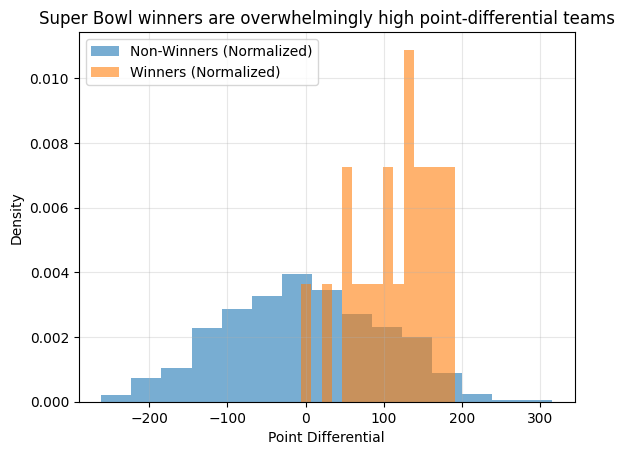

In [272]:
# ============================================
# Visualize Point Differential
# ============================================

plt.figure()

df[df["super_bowl_winner"] == 0]["points_diff"].hist(
    bins=15, density=True, alpha=0.6
)

df[df["super_bowl_winner"] == 1]["points_diff"].hist(
    bins=15, density=True, alpha=0.6
)

plt.title("Super Bowl winners are overwhelmingly high point-differential teams")
plt.xlabel("Point Differential")
plt.ylabel("Density")

plt.legend(["Non-Winners (Normalized)", "Winners (Normalized)"])
plt.grid(True, alpha=0.3)

plt.show()

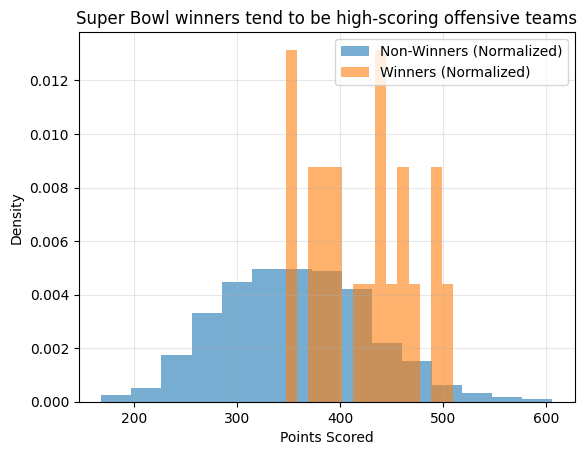

In [273]:
# ============================================
# Visualization: Points Scored
# ============================================

plt.figure()

df[df["super_bowl_winner"] == 0]["points"].hist(
    bins=15, density=True, alpha=0.6
)

df[df["super_bowl_winner"] == 1]["points"].hist(
    bins=15, density=True, alpha=0.6
)

plt.title("Super Bowl winners tend to be high-scoring offensive teams")
plt.xlabel("Points Scored")
plt.ylabel("Density")

plt.legend(["Non-Winners (Normalized)", "Winners (Normalized)"])
plt.grid(True, alpha=0.3)

plt.show()

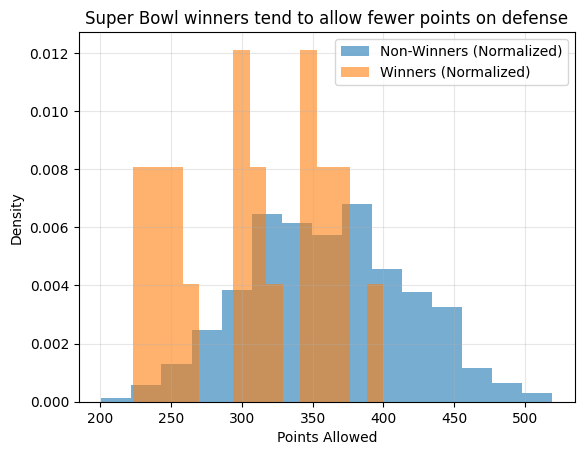

In [274]:
# ============================================
# Visualization: Points Allowed
# ============================================

plt.figure()

df[df["super_bowl_winner"] == 0]["points_opp"].hist(
    bins=15, density=True, alpha=0.6
)

df[df["super_bowl_winner"] == 1]["points_opp"].hist(
    bins=15, density=True, alpha=0.6
)

plt.title("Super Bowl winners tend to allow fewer points on defense")
plt.xlabel("Points Allowed")
plt.ylabel("Density")

plt.legend(["Non-Winners (Normalized)", "Winners (Normalized)"])
plt.grid(True, alpha=0.3)

plt.show()

### Visualization Insights

The distributions show clear differences between Super Bowl winners and non-winners:

- **Point Differential:**  
  Super Bowl-winning teams are heavily concentrated in the positive range, often between +50 and +200.  
  Non-winning teams are spread across both negative and positive values.  
  This suggests that overall dominance (outscoring opponents consistently) is a key characteristic of championship teams.

- **Points Scored:**  
  Winners tend to fall in the higher scoring ranges (approximately 350–500+ points), although there is some overlap with non-winning teams.  
  This indicates that strong offensive production is important but not sufficient on its own.

- **Points Allowed:**  
  Winning teams generally allow fewer points, clustering in the lower range (approximately 250–350).  
  Non-winning teams show a wider spread, including many teams that allow significantly more points.

Overall, these visualizations suggest that Super Bowl winners are typically well-balanced teams that combine strong offense with strong defense, rather than relying on a single dimension of performance.

In [275]:
# ============================================
# Correlation with Target Variable
# ============================================

correlations = df.corr(numeric_only=True)["super_bowl_winner"].sort_values(ascending=False)

correlations.head(10)

,super_bowl_winner
super_bowl_winner,1.000000
wins,0.223953
win_loss_perc,0.222986
points_diff,0.206740
mov,0.180292
points,0.157153
pass_net_yds_per_att,0.154330
score_pct,0.148449
pass_td,0.144327
exp_pts_tot,0.125809


### Correlation Insights

The correlation analysis provides quantitative support for the patterns observed in the visualizations:

- **Wins and Win Percentage** show the strongest relationship with Super Bowl success, indicating that overall team success during the regular season is a major factor.

- **Point Differential and Margin of Victory (mov)** are also highly correlated with the target variable, reinforcing the idea that dominant teams (those that consistently outscore opponents) are more likely to win championships.

- **Points Scored** has a moderate positive correlation, suggesting that strong offensive performance contributes to success.

- Efficiency-based metrics such as **pass_net_yds_per_att** and **score_pct** also show meaningful relationships, indicating that how efficiently a team performs can matter in addition to raw totals.

Overall, the correlation results confirm that Super Bowl winners are not defined by a single statistic, but by a combination of:
- consistent winning,
- scoring efficiency,
- and overall dominance across the season.

These findings will guide feature selection in the modeling phase.

### EDA Summary

The exploratory analysis shows that Super Bowl winners tend to:
- have stronger scoring output,
- allow fewer points,
- and maintain stronger overall point differentials than non-winners.

These findings suggest that championship teams are characterized by overall team strength rather than a single isolated metric.

This directly motivates the use of multiple team-performance variables in the modeling stage and supports the decision to compare both full and reduced feature sets.

### Cleaning Summary Before Modeling

Before modeling, the dataset required several preparation steps:

- Missing values were identified and handled using median imputation based on the training data only.
- Identifier columns such as `team` and `year` were excluded from model inputs.
- Redundant and outcome-based variables were removed from the clean feature set to reduce leakage and improve interpretability.

These decisions were made to ensure that the modeling process remained reproducible, realistic, and methodologically sound.

## 4. Feature Selection and Justification

In this section, we define which variables will be used for modeling.

We construct two feature sets:
- A full feature set that includes all available predictors
- A reduced feature set that removes redundant or outcome-based variables

This allows us to compare model performance and better understand which features truly drive predictions.

In [276]:
# ============================================
# Full Feature Set
# ============================================

features_full = df.drop(columns=["super_bowl_winner", "team", "year"])

X_full = features_full
y = df["super_bowl_winner"]

print("Full feature set shape:", X_full.shape)

Full feature set shape: (672, 33)


In [277]:
# ============================================
# Clean Feature Set (Reduced)
# ============================================

features_clean = df.drop(columns=[
    "super_bowl_winner",
    "team",
    "year",
    "wins",
    "win_loss_perc",
    "points_diff",
    "mov"
])

X_clean = features_clean

print("Clean feature set shape:", X_clean.shape)

Clean feature set shape: (672, 29)


### Feature Selection Rationale

Two different feature sets were created for this project.

**Full Feature Set**
- Includes nearly all available predictors except identifiers such as `team` and `year`
- Used to observe how a more permissive model behaves

**Clean Feature Set**
- Excludes variables that are either too close to the final outcome or mathematically redundant

The following variables were removed from the clean feature set:

- **wins** and **win_loss_perc**  
  These are highly outcome-based and are very close to the result we are trying to predict. Including them would make the problem less meaningful.

- **points_diff** and **mov**  
  These are summary variables derived from scoring outcomes and overlap heavily with more fundamental features such as points scored and points allowed.

This clean feature set is intended to produce a more honest and interpretable model by relying on core team-performance metrics rather than highly compressed season summaries.

## 5. Train-Test Split

The dataset is split based on time rather than randomly.

This ensures:
- training uses past data
- testing uses future data

This avoids data leakage and reflects real-world prediction.

In [278]:
# ============================================
# Train-Test Split (Time-Based)
# ============================================

train = df[df["year"] < 2019]
test = df[df["year"] >= 2019]

X_train_full = train.drop(columns=["super_bowl_winner", "team", "year"])
y_train = train["super_bowl_winner"]

X_test_full = test.drop(columns=["super_bowl_winner", "team", "year"])
y_test = test["super_bowl_winner"]

print("Train size:", X_train_full.shape)
print("Test size:", X_test_full.shape)

Train size: (512, 33)
Test size: (160, 33)


### Train-Test Split Rationale

The data was split based on time rather than randomly.

- Training set: earlier seasons  
- Test set: recent seasons  

This simulates real-world prediction, where future outcomes are unknown.

This approach avoids data leakage and ensures a realistic evaluation of model performance.

In [279]:
# Clean version split

X_train_clean = train.drop(columns=[
    "super_bowl_winner", "team", "year",
    "wins", "win_loss_perc", "points_diff", "mov"
])

X_test_clean = test.drop(columns=[
    "super_bowl_winner", "team", "year",
    "wins", "win_loss_perc", "points_diff", "mov"
])

## 6. Data Preprocessing

### Preprocessing Overview

Before any model can be fit, the feature matrices must be checked for issues that would prevent successful training.

In particular, this section verifies whether the training and test sets contain missing values, then applies imputation and feature scaling where appropriate.

Random Forest does not require scaling.

### Model Selection Rationale

Two models were chosen:

### Logistic Regression
- Serves as a baseline model
- Interpretable and effective for structured data

### Random Forest
- Captures nonlinear relationships
- Handles feature interactions automatically

Comparing these models allows us to determine whether increased complexity improves performance.

In [280]:
# ============================================
# Modeling Imports
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

In [281]:
# ============================================
# Check Missing Values in Training Features
# ============================================

missing_train_full = X_train_full.isnull().sum()
missing_train_full = missing_train_full[missing_train_full > 0].sort_values(ascending=False)

print("Columns with missing values in X_train_full:")
print(missing_train_full)

Columns with missing values in X_train_full:
ties    320
mov     192
dtype: int64


In [282]:
# ============================================
# Check Missing Values in Test Features
# ============================================

missing_test_full = X_test_full.isnull().sum()
missing_test_full = missing_test_full[missing_test_full > 0].sort_values(ascending=False)

print("Columns with missing values in X_test_full:")
print(missing_test_full)

Columns with missing values in X_test_full:
mov     128
ties     32
dtype: int64


In [283]:
# ============================================
# Impute Missing Values (Full Feature Set)
# ============================================

train_medians_full = X_train_full.median(numeric_only=True)

X_train_full = X_train_full.fillna(train_medians_full)
X_test_full = X_test_full.fillna(train_medians_full)

print("Remaining missing values in X_train_full:", X_train_full.isnull().sum().sum())
print("Remaining missing values in X_test_full:", X_test_full.isnull().sum().sum())

Remaining missing values in X_train_full: 0
Remaining missing values in X_test_full: 0


In [284]:
# ============================================
# Impute Missing Values (Clean Feature Set)
# ============================================

train_medians_clean = X_train_clean.median(numeric_only=True)

X_train_clean = X_train_clean.fillna(train_medians_clean)
X_test_clean = X_test_clean.fillna(train_medians_clean)

print("Remaining missing values in X_train_clean:", X_train_clean.isnull().sum().sum())
print("Remaining missing values in X_test_clean:", X_test_clean.isnull().sum().sum())

Remaining missing values in X_train_clean: 0
Remaining missing values in X_test_clean: 0


### Missing-Value Handling Before Modeling

Some predictor columns contained missing values, which prevented logistic regression from fitting.

To address this, missing numeric values were imputed using the median of each feature computed from the training set only. The same training-set medians were then applied to the test set.

This approach avoids data leakage while allowing the model to train on a complete feature matrix.

In [285]:
# ============================================
# Scale Features (Full Feature Set)
# ============================================

scaler_full = StandardScaler()

X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

print("Full feature set scaled.")
print("Scaled train shape:", X_train_full_scaled.shape)
print("Scaled test shape:", X_test_full_scaled.shape)

Full feature set scaled.
Scaled train shape: (512, 33)
Scaled test shape: (160, 33)


In [286]:
# ============================================
# Scale Features (Clean Feature Set)
# ============================================

scaler_clean = StandardScaler()

X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

print("Clean feature set scaled.")
print("Scaled train shape:", X_train_clean_scaled.shape)
print("Scaled test shape:", X_test_clean_scaled.shape)

Clean feature set scaled.
Scaled train shape: (512, 29)
Scaled test shape: (160, 29)


### Feature Scaling Before Logistic Regression

Logistic regression is sensitive to differences in feature scale. Since the predictor variables in this dataset are measured on very different numerical ranges, the features were standardized before model fitting.

The scaler was fit on the training data only and then applied to the test data. This avoids data leakage while improving model stability and optimizer convergence.

## 7. Baseline Model: Logistic Regression

Logistic regression is used as the baseline classification model for this project.

We evaluate two versions:
- a full-feature model, which includes all available predictors except identifiers,
- and a reduced clean-feature model, which excludes redundant or outcome-based variables.

This allows us to compare predictive performance while also testing whether a more interpretable and less leakage-prone feature set can still identify strong Super Bowl contenders.

In [287]:
# ============================================
# Train Logistic Regression (Full Features)
# ============================================

model_full = LogisticRegression(max_iter=5000, class_weight="balanced")

model_full.fit(X_train_full_scaled, y_train)

print("Full model trained.")

Full model trained.


In [288]:
# ============================================
# Predictions (Full Model)
# ============================================

y_pred_full = model_full.predict(X_test_full_scaled)

### Understanding the Confusion Matrix

A confusion matrix shows how predictions compare to actual outcomes.

Because this dataset is highly imbalanced:
- accuracy is misleading
- we must look at how well the model identifies winners

**Accuracy is misleading in this problem due to extreme class imbalance.**

### Why the Classification Report Matters

In addition to the confusion matrix, the classification report provides precision, recall, and F1-score for each class.

These metrics are especially important here because the positive class is extremely rare. They help show whether the model is actually identifying winners rather than just achieving high overall accuracy by predicting non-winners.

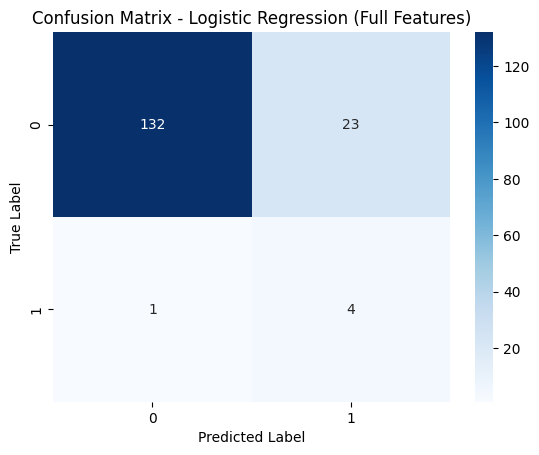

Classification Report (Full Model):
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       155
           1       0.15      0.80      0.25         5

    accuracy                           0.85       160
   macro avg       0.57      0.83      0.58       160
weighted avg       0.97      0.85      0.90       160



In [289]:
# ============================================
# Evaluation (Full Model)
# ============================================

cm_full = confusion_matrix(y_test, y_pred_full)

plt.figure()
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (Full Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Classification Report (Full Model):")
print(classification_report(y_test, y_pred_full))

In [290]:
# ============================================
# Train Logistic Regression (Clean Features)
# ============================================

model_clean = LogisticRegression(max_iter=5000, class_weight="balanced")
model_clean.fit(X_train_clean_scaled, y_train)

print("Clean model trained.")

Clean model trained.


In [291]:
# ============================================
# Predictions (Clean Model)
# ============================================

y_pred_clean = model_clean.predict(X_test_clean_scaled)

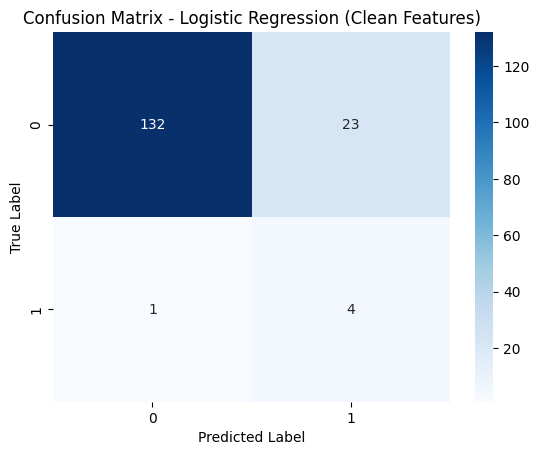

Classification Report (Clean Model):
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       155
           1       0.15      0.80      0.25         5

    accuracy                           0.85       160
   macro avg       0.57      0.83      0.58       160
weighted avg       0.97      0.85      0.90       160



In [292]:
# ============================================
# Evaluation (Clean Model)
# ============================================

cm_clean = confusion_matrix(y_test, y_pred_clean)

plt.figure()
sns.heatmap(cm_clean, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (Clean Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Classification Report (Clean Model):")
print(classification_report(y_test, y_pred_clean))

### First Modeling Result

The initial logistic regression results show that binary winner prediction is extremely difficult in this dataset.

Both the full and clean models are heavily affected by class imbalance, since only one team per season is labeled as a Super Bowl winner. As a result, the models tend to predict the majority class and fail to identify winners when using the default threshold.

This stricter evaluation may appear worse than a simpler setup, but it is methodologically stronger. It reflects the real difficulty of the problem rather than inflating performance through misleading metrics or overly easy feature choices.

For that reason, the analysis now shifts from strict binary prediction toward predicted probabilities and ranking-based evaluation.

## 8. Ranking-Based Evaluation

Because the default binary predictions are limited by class imbalance, the next step is to examine predicted probabilities.

Rather than asking whether the model predicts the exact winner as class 1, we instead ask whether the model assigns relatively high probabilities to strong teams. This reframes the problem from strict classification toward ranking likely contenders.

In [293]:
# ============================================
# Predicted Probabilities (Clean Model)
# ============================================

y_probs = model_clean.predict_proba(X_test_clean_scaled)[:, 1]

test_results = test.copy()
test_results["predicted_probability"] = y_probs

test_results.sort_values(by="predicted_probability", ascending=False).head(10)

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,pass_att,pass_yds,pass_td,pass_int,pass_net_yds_per_att,pass_fd,rush_att,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties,super_bowl_winner,predicted_probability
512,2019,New England Patriots,12,4,0.750,420,225,195,NaN,16,5664,1095,5.2,15,6,338,378,620,3961,25,9,6.1,197,447,1703,17,3.8,110,94,828,31,36.3,7.4,34.62,0.0,0,0.983642
524,2019,Kansas City Chiefs,12,4,0.750,451,308,143,NaN,16,6067,976,6.2,15,10,350,378,576,4498,30,5,7.5,211,375,1569,16,4.2,93,107,1029,46,48.8,7.9,263.38,0.0,1,0.967456
544,2020,Buffalo Bills,13,3,0.813,501,375,126,NaN,16,6343,1034,6.1,22,11,397,410,596,4620,40,11,7.4,240,411,1723,16,4.2,119,102,941,38,49.4,11.8,228.66,0.0,0,0.940609
668,2023,San Francisco 49ers,12,5,0.706,491,298,193,11.4,17,6773,1024,6.6,18,6,383,336,491,4384,33,12,8.4,207,499,2389,27,4.8,147,101,933,29,45.3,10.1,231.48,NaN,0,0.938441
556,2020,Kansas City Chiefs,14,2,0.875,473,362,111,NaN,16,6653,1057,6.3,16,9,397,420,630,4854,40,7,7.4,255,403,1799,13,4.5,110,105,919,32,47.9,9.2,280.82,0.0,0,0.916090
624,2022,Philadelphia Eagles,14,3,0.824,477,344,133,NaN,17,6614,1124,5.9,19,10,385,350,536,4105,25,9,7.1,195,544,2509,32,4.6,161,90,682,29,42.5,10.2,226.96,0.0,0,0.906748
620,2022,Kansas City Chiefs,14,3,0.824,496,369,127,NaN,17,7032,1094,6.4,23,11,408,435,651,5062,41,12,7.5,272,417,1970,18,4.7,105,87,838,31,46.4,10.1,281.00,0.0,1,0.900211
600,2021,Tampa Bay Buccaneers,13,4,0.765,511,353,158,NaN,17,6901,1139,6.1,19,7,404,492,731,5229,43,12,6.9,273,385,1672,18,4.3,106,97,874,25,44.3,9.8,216.14,0.0,0,0.871666
568,2020,New Orleans Saints,12,4,0.750,482,337,145,NaN,16,6023,1045,5.8,17,9,367,370,522,3758,28,8,6.8,199,494,2265,30,4.6,147,98,1005,21,45.5,9.0,176.94,0.0,0,0.870437
644,2023,Baltimore Ravens,13,4,0.765,483,280,203,11.9,17,6296,1076,5.9,19,12,360,328,494,3635,27,7,6.8,180,541,2661,26,4.9,145,102,955,35,43.1,9.6,130.64,NaN,0,0.846366


In [294]:
# ============================================
# Actual Winners in the Test Set
# ============================================

test_results[test_results["super_bowl_winner"] == 1].sort_values(
    by="predicted_probability", ascending=False
)[["year", "team", "predicted_probability"]]

,year,team,predicted_probability
524,2019,Kansas City Chiefs,0.967456
620,2022,Kansas City Chiefs,0.900211
569,2020,Tampa Bay Buccaneers,0.655587
604,2021,Los Angeles Rams,0.581922
652,2023,Kansas City Chiefs,0.418783


In [295]:
# ============================================
# Top Ranked Team Each Year
# ============================================

test_results.sort_values(
    ["year", "predicted_probability"], ascending=[True, False]
).groupby("year").head(5)[["year", "team", "super_bowl_winner", "predicted_probability"]]

,year,team,super_bowl_winner,predicted_probability
512,2019,New England Patriots,0,0.983642
524,2019,Kansas City Chiefs,1,0.967456
516,2019,Baltimore Ravens,0,0.657773
540,2019,San Francisco 49ers,0,0.571573
532,2019,Green Bay Packers,0,0.505316
544,2020,Buffalo Bills,0,0.940609
556,2020,Kansas City Chiefs,0,0.916090
568,2020,New Orleans Saints,0,0.870437
553,2020,Indianapolis Colts,0,0.810415
548,2020,Pittsburgh Steelers,0,0.776394


In [296]:
# ============================================
# Probability Summary
# ============================================

test_results["predicted_probability"].describe()

,predicted_probability
count,160.000000
mean,0.197093
std,0.282538
min,0.000003
25%,0.009372
50%,0.046912
75%,0.287558
max,0.983642


### Limitations of Binary Classification

The results show that logistic regression fails to predict any Super Bowl winners when using the default classification threshold. This is due to the extreme class imbalance in the dataset, where only one team per season is labeled as a winner.

As a result, the model defaults to predicting the majority class (non-winners), which produces high accuracy but no useful insight.

However, the predicted probabilities reveal that the model still assigns higher likelihoods to strong teams. This indicates that the model captures meaningful patterns in team performance, even if it cannot confidently classify winners.

Because of this, the problem is better framed as a **ranking problem rather than a strict classification problem**.

### Top-K Evaluation

Predicting the exact Super Bowl winner is extremely difficult.

Instead, we evaluate whether the model identifies **top contenders**.

Top-K measures whether the actual winner appears in the top K ranked teams.

This is more realistic because:
- multiple teams are legitimate contenders each year
- the best model should rank strong teams highly

This approach aligns more closely with real-world decision-making, where identifying a group of strong contenders is often more useful than predicting a single outcome with certainty.

In [297]:
# ============================================
# Top-K Evaluation (Ranking Performance)
# ============================================

def evaluate_top_k(df, k):
    correct = 0
    total = 0

    for year in df["year"].unique():
        year_df = df[df["year"] == year].sort_values(
            by="predicted_probability", ascending=False
        )

        top_k = year_df.head(k)

        if top_k["super_bowl_winner"].sum() > 0:
            correct += 1

        total += 1

    return correct, total, correct / total

for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(test_results, k)
    print(f"Top-{k} accuracy: {correct}/{total} = {acc:.2f}")

Top-1 accuracy: 0/5 = 0.00
Top-3 accuracy: 2/5 = 0.40
Top-5 accuracy: 4/5 = 0.80
Top-10 accuracy: 5/5 = 1.00


### Top-K Evaluation Insights

Evaluating the model using top-K accuracy provides a more realistic measure of performance.

Rather than requiring the model to predict the exact Super Bowl winner, this approach checks whether the winning team appears among the top-ranked teams by predicted probability.

The results show that while the model struggles with exact prediction, it performs much better at identifying strong contenders. This supports the conclusion that the model is more effective as a ranking system than a strict classifier.

## 9. Model Comparison

Random Forest is used to compare against logistic regression.

It captures nonlinear relationships and feature interactions.

This helps determine whether a more complex model improves performance.

### Why Random Forest Is Compared to Logistic Regression

Logistic regression serves as the baseline linear model for this project.

Random Forest is included because it can capture nonlinear relationships and interactions between variables that logistic regression may miss. If Random Forest performs better, that would suggest the data contains important nonlinear structure. If it does not, that suggests the simpler linear baseline may already capture most of the useful signal in this dataset.

This comparison is useful even if Random Forest does not win, because it helps determine whether the predictive signal is mostly linear or whether more complex relationships are present.

In [298]:
# ============================================
# Train Random Forest (Clean Features)
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_clean, y_train)

print("Random Forest trained.")

Random Forest trained.


In [299]:
# ============================================
# Predictions (Random Forest)
# ============================================

rf_preds = rf_model.predict(X_test_clean)

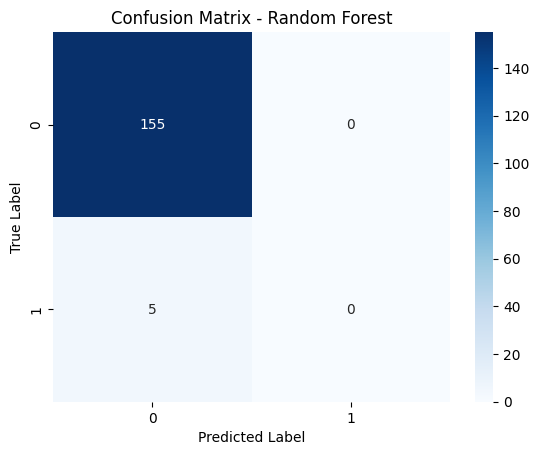

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       155
           1       0.00      0.00      0.00         5

    accuracy                           0.97       160
   macro avg       0.48      0.50      0.49       160
weighted avg       0.94      0.97      0.95       160



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [300]:
# ============================================
# Evaluation (Random Forest)
# ============================================

cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds))

In [301]:
# ============================================
# Probabilities (Random Forest)
# ============================================

rf_probs = rf_model.predict_proba(X_test_clean)[:, 1]

rf_results = test.copy()
rf_results["predicted_probability"] = rf_probs

rf_results.sort_values(by="predicted_probability", ascending=False).head(10)

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,pass_att,pass_yds,pass_td,pass_int,pass_net_yds_per_att,pass_fd,rush_att,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties,super_bowl_winner,predicted_probability
553,2020,Indianapolis Colts,11,5,0.688,451,362,89,NaN,16,6049,1032,5.9,15,4,364,371,552,4053,24,11,7.1,201,459,1996,20,4.3,129,94,899,34,44.4,8.8,168.41,0.0,0,0.342196
512,2019,New England Patriots,12,4,0.750,420,225,195,NaN,16,5664,1095,5.2,15,6,338,378,620,3961,25,9,6.1,197,447,1703,17,3.8,110,94,828,31,36.3,7.4,34.62,0.0,0,0.314543
533,2019,Minnesota Vikings,10,6,0.625,407,303,104,NaN,16,5656,970,5.8,20,12,314,319,466,3523,26,8,7.1,171,476,2133,19,4.5,106,96,895,37,41.6,10.4,98.01,0.0,0,0.272917
545,2020,Miami Dolphins,10,6,0.625,404,338,66,NaN,16,5424,1021,5.3,20,7,345,370,559,3736,24,13,6.3,207,428,1688,15,3.9,100,74,635,38,41.4,11.0,61.96,0.0,0,0.210085
606,2021,San Francisco 49ers,10,7,0.588,427,365,62,NaN,17,6387,1046,6.1,24,10,361,343,514,4221,26,14,7.7,200,499,2166,22,4.3,130,102,1066,31,41.2,11.5,130.03,0.0,0,0.208504
608,2022,Buffalo Bills,13,3,0.813,455,286,169,NaN,16,6361,1037,6.1,27,13,367,361,574,4129,35,14,6.8,212,430,2232,15,5.2,128,92,709,27,45.0,15.2,157.46,0.0,0,0.204916
596,2021,Green Bay Packers,13,4,0.765,450,371,79,NaN,17,6215,1072,5.8,13,6,375,402,593,4315,39,7,6.9,235,446,1900,13,4.3,109,69,678,31,44.5,6.4,180.42,0.0,0,0.191658
577,2021,New England Patriots,10,7,0.588,462,303,159,NaN,17,6008,1052,5.7,23,10,362,364,535,3857,24,13,6.9,187,489,2151,24,4.4,139,95,854,36,48.0,12.6,126.97,0.0,0,0.189991
580,2021,Cincinnati Bengals,10,7,0.588,460,376,84,NaN,17,6145,1046,5.9,21,7,337,384,555,4403,36,14,7.2,208,436,1742,16,4.0,96,72,620,33,42.6,10.0,118.50,0.0,0,0.186810
532,2019,Green Bay Packers,13,3,0.813,376,313,63,NaN,16,5528,1020,5.4,13,9,320,356,573,3733,26,4,6.1,190,411,1795,18,4.4,90,100,774,40,37.3,6.8,113.40,0.0,0,0.182454


In [302]:
# ============================================
# Top-K Evaluation (Random Forest)
# ============================================

for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(rf_results, k)
    print(f"Random Forest Top-{k}: {correct}/{total} = {acc:.2f}")

Random Forest Top-1: 0/5 = 0.00
Random Forest Top-3: 0/5 = 0.00
Random Forest Top-5: 0/5 = 0.00
Random Forest Top-10: 4/5 = 0.80


### Visual Comparison of Top-K Performance

The table-style Top-K results are useful, but a direct visual comparison makes it easier to see how the two models differ across increasingly broad contender definitions.

This figure summarizes which model is more effective at placing the eventual Super Bowl winner among the top-ranked teams in each season.

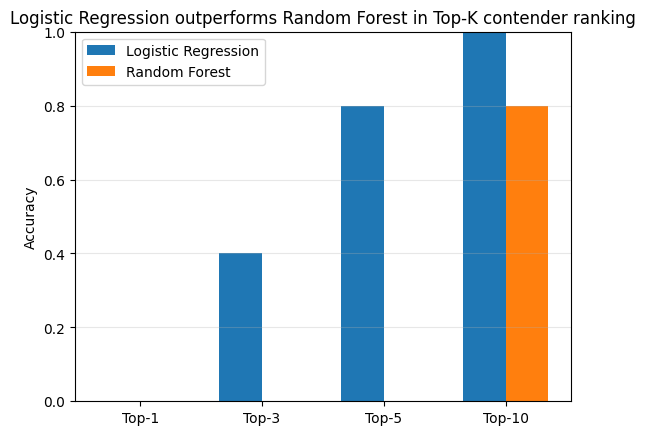

In [303]:
# ============================================
# Top-K Comparison Bar Chart
# ============================================

topk_labels = ["Top-1", "Top-3", "Top-5", "Top-10"]

logistic_scores = [evaluate_top_k(test_results, k)[2] for k in [1, 3, 5, 10]]
rf_scores = [evaluate_top_k(rf_results, k)[2] for k in [1, 3, 5, 10]]

x = np.arange(len(topk_labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, logistic_scores, width, label="Logistic Regression")
plt.bar(x + width/2, rf_scores, width, label="Random Forest")

plt.xticks(x, topk_labels)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Logistic Regression outperforms Random Forest in Top-K contender ranking")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Why This Comparison Plot Matters

This chart summarizes the most meaningful evaluation in the project: whether the models successfully rank the eventual Super Bowl winner among the strongest teams in each season.

Because binary winner prediction is so difficult in this dataset, the Top-K comparison provides a clearer view of which model is more useful for identifying realistic contenders.

In [304]:
# ============================================
# Model Comparison Summary
# ============================================

print("Logistic Regression Top-K:")
for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(test_results, k)
    print(f"Top-{k}: {correct}/{total} = {acc:.2f}")

print("\nRandom Forest Top-K:")
for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(rf_results, k)
    print(f"Top-{k}: {correct}/{total} = {acc:.2f}")

Logistic Regression Top-K:
Top-1: 0/5 = 0.00
Top-3: 2/5 = 0.40
Top-5: 4/5 = 0.80
Top-10: 5/5 = 1.00

Random Forest Top-K:
Top-1: 0/5 = 0.00
Top-3: 0/5 = 0.00
Top-5: 0/5 = 0.00
Top-10: 4/5 = 0.80


### Model Comparison Summary Interpretation

Random Forest did not significantly outperform Logistic Regression.

This suggests:
- the dataset may not contain strong nonlinear relationships,
- or that the dataset size is too small for complex models.

This highlights an important insight:
> simpler models can perform just as well when the underlying signal is strong and mostly linear.

This is likely due to the combination of small dataset size and extreme class imbalance, which limits the ability of more complex models to generalize effectively.

## 10. Threshold Tuning

The default logistic regression threshold of 0.5 is often too strict for highly imbalanced problems like this one.

To explore whether the model can recover more true winners, the threshold is lowered so that smaller predicted probabilities can still produce a positive prediction.

This does not retrain the model. It only changes how probabilities are converted into class labels, making it a useful refinement step after the baseline results and model comparison have already been established.

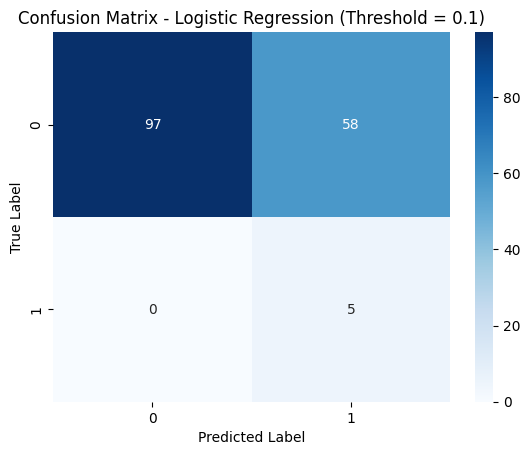

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.63      0.77       155
           1       0.08      1.00      0.15         5

    accuracy                           0.64       160
   macro avg       0.54      0.81      0.46       160
weighted avg       0.97      0.64      0.75       160



In [305]:
# ============================================
# Threshold Tuning (Clean Logistic)
# ============================================

threshold = 0.10  # try 0.05, 0.10, 0.15

y_pred_thresh = (y_probs >= threshold).astype(int)

cm_thresh = confusion_matrix(y_test, y_pred_thresh)

plt.figure()
sns.heatmap(cm_thresh, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Logistic Regression (Threshold = {threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_thresh))

## 11. Final Discussion and Limitations

This project shows that Super Bowl-winning teams tend to be distinguished by overall team dominance, especially in metrics related to scoring margin, scoring output, and defensive strength.

At the same time, exact binary prediction of winners is extremely difficult because:

- the dataset is highly imbalanced,
- the dataset size is relatively small (one winner per season), limiting the ability of more complex models to learn robust patterns.
- and regular-season statistics do not capture every factor that affects postseason success.

The strongest conclusion is not that the models can perfectly predict the Super Bowl winner. Instead, the more honest and useful conclusion is that they can identify a smaller group of realistic contenders and rank strong teams near the top.

That is still a meaningful result. In a problem this difficult, a useful ranking of contenders is more realistic, more defensible, and more informative than pretending exact winner prediction is easy.

### Specific Limitations

- Only one winner per season creates extreme class imbalance.
- The dataset does not include contextual factors such as injuries or playoff performance.
- Regular-season statistics may not fully capture postseason success.

Future work could include:
- more detailed features,
- playoff-specific data,
- or advanced modeling techniques.

## 12. Ethical Considerations

This project uses publicly available NFL team statistics and does not involve personal or sensitive information.

However, ethical concerns still exist:

- **Results could be misused or misinterpreted.**  
  A model like this could be mistaken for a reliable betting or decision-making system, even though it is built on historical regular-season data and has clear limitations.

- **Historical patterns may not fully generalize.**  
  Team success depends on many changing factors such as injuries, coaching decisions, postseason matchups, and roster turnover, none of which are fully captured here.

To address these concerns, the analysis has been written conservatively and the limitations have been stated explicitly. The model should be understood as an educational and analytical tool, not as a guaranteed predictive system.

These concerns are especially important in sports analytics because predictive models are often treated as more certain than they really are.

## 13. Reproducibility

This notebook was designed to be reproducible from top to bottom on a clean kernel.

Steps taken to support reproducibility include:
- setting random seeds where randomness is involved,
- using a single notebook for the full workflow,
- documenting each major decision in markdown,
- separating training and test logic carefully,
- imputing missing values using training-set statistics only,
- relying on clearly identified Python libraries used throughout the notebook,
- and applying scaling only where required.

The notebook is also linked to the group GitHub repository so that the full workflow, documentation, and project history can be reviewed outside the notebook itself.